In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
student_df = pd.read_csv("Student_performance_data _.csv")

In [8]:
student_df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [10]:
student_df.info()
student_df.describe()
student_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [18]:
student_df.drop("StudentID",axis=1,inplace=True)

In [20]:
student_df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


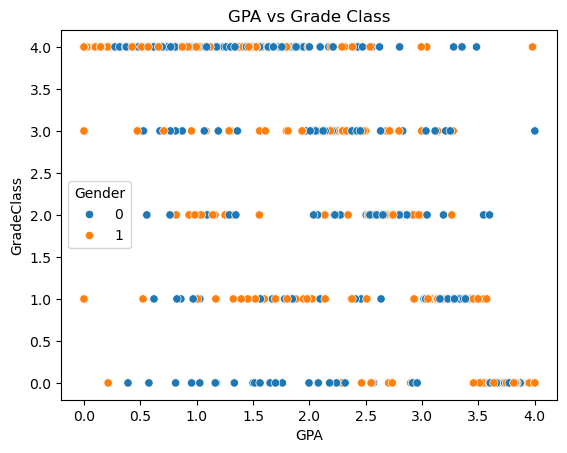

In [16]:
sns.scatterplot(
    data=student_df,
    x="GPA",
    y="GradeClass",
    hue="Gender"
)

plt.title("GPA vs Grade Class")
plt.show()

In [22]:
X = student_df.drop("GradeClass",axis=1)
y = student_df["GradeClass"]

In [25]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [31]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test)

In [33]:
y_pred

array([4., 2., 4., 1., 4., 2., 4., 3., 3., 4., 3., 4., 1., 3., 2., 4., 4.,
       4., 4., 3., 4., 4., 4., 2., 4., 4., 4., 2., 3., 3., 4., 4., 1., 1.,
       4., 4., 1., 2., 0., 4., 2., 1., 4., 4., 4., 3., 2., 4., 2., 4., 2.,
       1., 4., 4., 4., 0., 3., 1., 4., 4., 4., 4., 2., 4., 4., 3., 1., 2.,
       4., 1., 1., 4., 2., 2., 4., 2., 4., 4., 4., 4., 4., 1., 3., 4., 4.,
       4., 1., 4., 4., 4., 3., 4., 4., 4., 4., 4., 1., 4., 4., 4., 4., 3.,
       4., 4., 4., 3., 2., 4., 4., 4., 4., 2., 1., 4., 4., 4., 4., 2., 4.,
       3., 4., 1., 1., 4., 4., 4., 1., 4., 3., 2., 4., 1., 2., 4., 4., 4.,
       3., 4., 4., 4., 2., 4., 1., 4., 2., 4., 4., 3., 1., 4., 0., 4., 1.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 2., 1.,
       4., 1., 2., 4., 4., 3., 2., 4., 3., 4., 2., 4., 4., 2., 2., 2., 1.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 3., 2., 2., 4., 2., 4., 2.,
       3., 3., 4., 2., 3., 4., 4., 4., 4., 2., 2., 4., 2., 1., 4., 2., 4.,
       2., 1., 4., 4., 4.

In [34]:
y_test

1004    4.0
196     1.0
2342    2.0
1708    0.0
435     4.0
       ... 
986     4.0
120     3.0
283     3.0
1740    2.0
1726    4.0
Name: GradeClass, Length: 479, dtype: float64

In [54]:
print(classification_report(y_test, y_pred))

print("Accuracy Score : ",accuracy_score(y_test,y_pred)*100)
print("Precision Score : " , precision_score(y_test, y_pred, average="weighted")*100)
print("Recall Score : ",recall_score(y_test, y_pred, average="weighted")*100)
print("F1 Score : ",f1_score(y_test, y_pred, average="weighted")*100)

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        22
         1.0       0.43      0.47      0.45        49
         2.0       0.60      0.62      0.61        85
         3.0       0.70      0.55      0.61        86
         4.0       0.88      0.98      0.92       237

    accuracy                           0.74       479
   macro avg       0.52      0.52      0.52       479
weighted avg       0.71      0.74      0.72       479

Accuracy Score :  74.11273486430062
Precision Score :  70.91801234515064
Recall Score :  74.11273486430062
F1 Score :  72.18705859591931


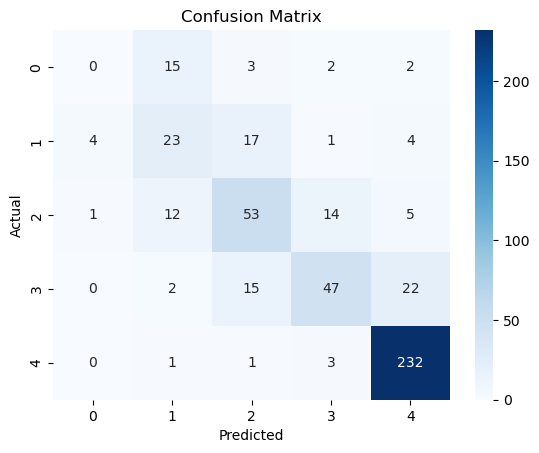

In [51]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [56]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

In [57]:
importance

,Feature,Coefficient
0,Age,-0.070790
1,Gender,-0.430117
2,Ethnicity,0.094667
3,ParentalEducation,-0.009716
4,StudyTimeWeekly,0.021420
5,Absences,0.046198
6,Tutoring,0.440339
7,ParentalSupport,0.174118
8,Extracurricular,0.152683
9,Sports,-0.270986
